In [56]:
# ==========================================
# IMPORTS & SETUP
# ==========================================
# Standard libraries
import re
import json
import string
import itertools
import textwrap
from collections import Counter

# Data manipulation and NLP
import pandas as pd
import numpy as np
import nltk
from nltk.collocations import BigramCollocationFinder
import pymorphy2
from stop_words import get_stop_words

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Prozhito specific library
from prozhitotools import dump

# Initialize NLP tools
morph = pymorphy2.MorphAnalyzer()
stoplist = get_stop_words('ru') + ['среди', 'аа', 'некий', 'либо', 'видимо', 'итак', 'словно', 'наверное', 'возможно', '-й', '-х', 'например', 'что-нибудь', 'вместо', 'кто-то', 'несмотря', 'коли', 'безъ', 'нѣтъ', 'всѣхъ', 'поэтому', 'почему-то', 'ибо', 'из-за', 'можетъ', 'неужели', 'дѣть', 'намъ', 'оттого', 'чрез', 'вероятно', 'многий', 'ах', 'пред', 'пусть', 'нынче', 'б', 'дабы', 'чрезвычайно', 'разумеется', 'вовсе', 'кн', 'гр', 'св', '-го', 'кой', 'франц.', 'оный', 'сей', 'свой', 'едва', 'самый', 'го', 'мол', 'час', 'часы', 'ть', 'минута', 'метр', 'г.', 'ко', 'въ', 'съ', 'мнѣ', 'къ', 'какъ', 'отъ', 'такъ', 'ежели', 'себѣ', 'былъ', 'онъ', 'томъ', 'сие', 'нрзб', 'изъ', 'тѣмъ', 'ихъ', 'чѣмъ', 'всѣ', 'com', 'id', 'de', 'la', 'et', 'le', 'que', 'je', 'il', 'est', 'les', 'un', 'id=', 'ii', 'г.', 'ч', 'м.', 'в.', 'my', 'of', 'ген', 'гл', 'авный']
extended_punctuation = string.punctuation + '\'\'" №~—»«..``’.--–“”―…"''" ...'

In [69]:
# ==========================================
# LOAD DATABASE & APPLY REGEX FILTERS
# ==========================================
# This section parses the entire Prozhito XML dump (~384k records). 
# It utilizes a positive regex to capture metaphorical and somatic heat expressions, 
# and a negative regex to aggressively filter out literal weather and medical illnesses.

# Replace with your actual file path
dw = dump.Wrapper(csvpath='/path/to/prozhito-dump-1')

positive_pattern = re.compile(
    r'\b(?:'
    r'(?:душевн\w+|внутренн\w+|любовн\w+|тайн\w+|сладк\w+|священн\w+)\s+(?:\w+\s+){0,2}(?:жар\w*|бред\w*|огонь|плам\w*)|'
    r'(?:жар\w*|бред\w*|огонь|плам\w*)\s+(?:\w+\s+){0,2}(?:душевн\w+|внутренн\w+|любовн\w+|тайн\w+|сладк\w+|священн\w+)|'
    r'(?:жар\w*|бред\w*|огонь|пламя)\s+(?:\w+\s+){0,2}(?:в\s+груди|в\s+сердце|в\s+душе|в\s+теле|любви|страсти|стыда|чувств)|'
    r'(?:в\s+груди|в\s+сердце|в\s+душе|в\s+теле|любви|страсти|стыда|чувств)\s+(?:\w+\s+){0,2}(?:жар\w*|бред\w*|огонь|пламя)|'
    r'(?:тело|лицо|душа|сердце|кровь|грудь)\s+(?:\w+\s+){0,2}(?:горит|пылает|кипит)|'
    r'(?:горит|пылает|кипит)\s+(?:\w+\s+){0,2}(?:тело|лицо|душа|сердце|кровь|грудь)|'
    r'(?:горю|пылаю|сгораю|вспыхнул\w*)\s+(?:\w+\s+){0,2}(?:от\s+страсти|от\s+любви|от\s+нетерпения|от\s+стыда|в\s+огне|чувств\w*)|'
    r'(?:от\s+страсти|от\s+любви|от\s+нетерпения|от\s+стыда|в\s+огне|чувств\w*)\s+(?:\w+\s+){0,2}(?:горю|пылаю|сгораю|вспыхнул\w*)|'
    r'(?:покраснел\w*|красне\w*|вспыхнул\w*)\s+(?:\w+\s+){0,2}(?:лиц\w*|щ[её]к\w*)|'
    r'(?:лиц\w*|щ[её]к\w*)\s+(?:\w+\s+){0,2}(?:покраснел\w*|красне\w*|вспыхнул\w*)|'
    r'(?:как(?:\s+будто)?|словно|будто)\s+(?:в\s+)?лихорадк\w*|'
    r'я\s+(?:\w+\s+){0,2}(?:горю|пылаю|сгораю|вспыхнул\w*|в\s+огне)|'
    r'(?:горю|пылаю|сгораю|вспыхнул\w*|в\s+огне)\s+(?:\w+\s+){0,2}я|'
    r'(?:брос[аи]\w*|кида\w*|кину\w*)\s+(?:\w+\s+){0,3}в\s+жар|'
    r'в\s+жар\s+(?:\w+\s+){0,3}(?:брос[аи]\w*|кида\w*|кину\w*)'
    r')\b', re.IGNORECASE
)

negative_pattern = re.compile(
    r'\b(?:грипп\w*|простуд\w*|тиф\w*|температур\w*|термометр\w*|'
    r'градус\w*|врач\w*|доктор\w*|озноб\w*|кашель|насморк|'
    r'заболел\w*|болен\b|больна\b|больниц\w*|лекарств\w*|погод\w*|жарко\s+на\s+улице)\b', re.IGNORECASE
)

records_list = []

for note in dw.notes:
    try:
        text_lower = note.text.lower()
    except AttributeError:
        continue
    
    if positive_pattern.search(text_lower):
        if not negative_pattern.search(text_lower):
            records_list.append({
                "ID": getattr(note, 'ID', None),
                "Запись": note.text,
                "Автор": getattr(note, 'author', 'Неизвестен'),
                "ID дневника": getattr(note, 'diary_ID', None),
                "Дата": getattr(note, 'date', None)
            })

heat_records_df = pd.DataFrame(records_list)
print(f"Total concentrated records extracted: {len(heat_records_df)}")
print("\n")
print(heat_records_df.head())

Total concentrated records extracted: 302


       ID                                             Запись  \
0  265113  Суббота. Смотрели заводы и все те работы, кото...   
1  140341  Вторник. Между тем как наши знатные москвичи п...   
2  140483  Пятница. Вот что называется и *сыт* и *пьян*. ...   
3  140516  Понедельник. Минувшие два года сряду празднова...   
4  182606  Наконец, 1 сентября я увидел себя у врат Москв...   

                                  Автор  ID дневника            Дата  
0  #762 Николай Яковлевич Озерецковский          772   (1782, 6, 25)  
1          #507 Степан Петрович Жихарев          515  (1805, 12, 24)  
2          #507 Степан Петрович Жихарев          515   (1808, 1, 23)  
3          #507 Степан Петрович Жихарев          515    (1808, 3, 1)  
4     #799 Александр Васильевич Чичерин          809   (1812, 9, 13)  


In [3]:
# ==========================================
# HISTORICAL PERIOD GROUPING
# ==========================================
# Organizes the extracted records into 5 distinct historical eras.

heat_records_df['Дата'] = pd.to_datetime(heat_records_df['Дата'], format='(%Y, %m, %d)')

periods = {
    'Period 1': ('1798-12-31', '1898-12-31'),
    'Period 2': ('1898-12-31', '1938-12-31'),
    'Period 3': ('1938-12-31', '1947-12-31'),
    'Period 4': ('1947-12-31', '1979-12-31'),
    'Period 5': ('1979-12-31', '2017-12-31')
}

periods_data = {}
for p_name, (start_date, end_date) in periods.items():
    mask = (heat_records_df['Дата'] > start_date) & (heat_records_df['Дата'] <= end_date)
    periods_data[p_name] = heat_records_df.loc[mask, ['ID', 'Запись']].to_dict('records')

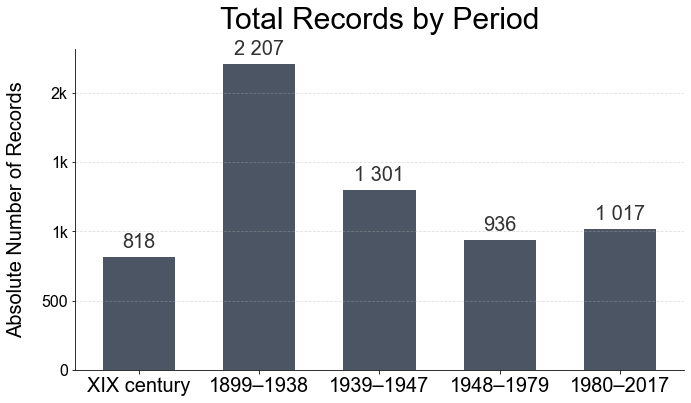

In [67]:
# ==========================================
# VISUALIZATION: TOTAL RECORDS BY PERIOD
# ==========================================
# This section generates a bar chart displaying the absolute total of diary records 
# retrieved from the Prozhito database for each historical period. 

periods = ['XIX century', '1899–1938', '1939–1947', '1948–1979', '1980–2017']
total_records = [818, 2207, 1301, 936, 1017] 

bar_color = '#4B5563'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Inter', 'Arial', 'Helvetica'], 
    'font.size': 20,          
    'axes.titlesize': 30,     
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 16,
    'figure.autolayout': True 
})

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(periods, total_records, color=bar_color, width=0.6)

for bar in bars:
    height = bar.get_height()
    formatted_height = f"{int(height):,}".replace(",", " ")
    
    ax.annotate(
        formatted_height,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  
        textcoords="offset points",
        ha='center', 
        va='bottom',
        fontsize=20,
        color='#333333'
    )

ax.set_title("Total Records by Period", pad=20)
ax.set_ylabel("Absolute Number of Records", labelpad=15)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else int(x)))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [11]:
# ==========================================
# TAG COMBINATION LOGIC & PERIOD STATISTICS
# ==========================================
# This section loads the manual annotations (Form, Emotion, Context), 
# calculates the rate of relevant records, splits records 
# containing multiple distinct heat events, and calculates the relative 
# frequency of tag combinations per period.

import json
from collections import Counter

# 1. Load the manual tags
with open('manual_tags.json', 'r', encoding='utf-8') as f:
    manual_tags = json.load(f)

# 2. Helper Functions
def should_exclude(tags):
    """Excludes records tagged as negative, irrelevant, or describing other subjects."""
    forbidden_tags = {"negative", "subject_other", "irrelevant"}
    if any(tag in forbidden_tags for tag in tags):
        return True
    
    # Exclude quotes that don't have enough form tags to warrant analysis
    if "quote" in tags:
        if sum(1 for tag in tags if tag.startswith("form_")) < 2:
            return True
            
    return False

def split_into_combinations(tags):
    """Splits tags into isolated chunks if a single record contains multiple distinct heat events."""
    combos = []
    current_combo = []
    has_form = False

    for tag in tags:
        if tag.startswith("form_"):
            if has_form:
                combos.append(current_combo)
                current_combo = [tag]
            else:
                current_combo.append(tag)
                has_form = True
        else:
            current_combo.append(tag)
            
    if current_combo:
        combos.append(current_combo)

    # Sort each combo for consistent output formatting
    sorted_combos = []
    for combo in combos:
        def sort_key(t):
            if t.startswith('form_'): return 0
            if t.startswith('feel_'): return 1
            if t.startswith('context_'): return 2
            return 3
            
        sorted_combo = tuple(sorted(combo, key=lambda x: (sort_key(x), x)))
        sorted_combos.append(sorted_combo)
        
    return sorted_combos

# 3. Baseline Statistics: Total Selected vs. Relevant Records
print("RECORD COUNTS PER PERIOD (Total Selected vs. Relevant)")
print("=" * 70)

grand_total_selected = 0
grand_total_relevant = 0

for period_name, records in periods_data.items():
    total_selected = len(records)
    # Count as relevant if the 'irrelevant' tag is missing
    relevant_count = sum(1 for r in records if "irrelevant" not in manual_tags.get(str(r['ID']), []))
    
    print(f"{period_name}: {total_selected} total selected | {relevant_count} relevant")
    
    grand_total_selected += total_selected
    grand_total_relevant += relevant_count

print("-" * 70)
print(f"GRAND TOTAL: {grand_total_selected} total selected | {grand_total_relevant} relevant\n\n")

# 4. Calculate and print tag combination statistics for each period
print("TOP 5 TAG COMBINATIONS PER PERIOD")
print("=" * 70)

for period_name, records in periods_data.items():
    combo_counts = Counter()
    valid_records_count = 0  # Tracks records that survive ALL exclusion rules
    
    for record in records:
        record_id = str(record['ID'])
        
        if record_id in manual_tags:
            tags = manual_tags[record_id]
            
            # Apply full exclusion rules (irrelevant, negative, subject_other, etc.)
            if should_exclude(tags):
                continue
                
            valid_records_count += 1
            
            for combo in split_into_combinations(tags):
                combo_counts[combo] += 1
                
    print(f"{period_name} (Valid records for analysis: {valid_records_count})")
    print("-" * 70)
    
    if not combo_counts:
        print("No valid tag combinations found.\n")
    else:
        for combo, count in combo_counts.most_common(5):
            formatted_combo = ", ".join(f'"{tag}"' for tag in combo)
            
            relative_freq = (count / valid_records_count) * 100
            
            print(f"{formatted_combo}: {count} ({relative_freq:.1f}%)")
    
    print("\n")

RECORD COUNTS PER PERIOD (Total Selected vs. Relevant)
Period 1: 41 total selected | 32 relevant
Period 2: 116 total selected | 91 relevant
Period 3: 68 total selected | 36 relevant
Period 4: 32 total selected | 24 relevant
Period 5: 44 total selected | 27 relevant
----------------------------------------------------------------------
GRAND TOTAL: 301 total selected | 210 relevant


TOP 5 TAG COMBINATIONS PER PERIOD
Period 1 (Valid records for analysis: 24)
----------------------------------------------------------------------
"form_somatic", "feel_love", "context_interpersonal": 4 (16.7%)
"form_metaphor", "feel_excitement", "context_creation": 3 (12.5%)
"form_somatic", "feel_anxiety", "context_interpersonal": 3 (12.5%)
"form_idiom", "feel_excitement", "context_politics": 2 (8.3%)
"form_metaphor", "feel_love", "context_religion": 2 (8.3%)


Period 2 (Valid records for analysis: 69)
----------------------------------------------------------------------
"form_metaphor", "feel_love", "con

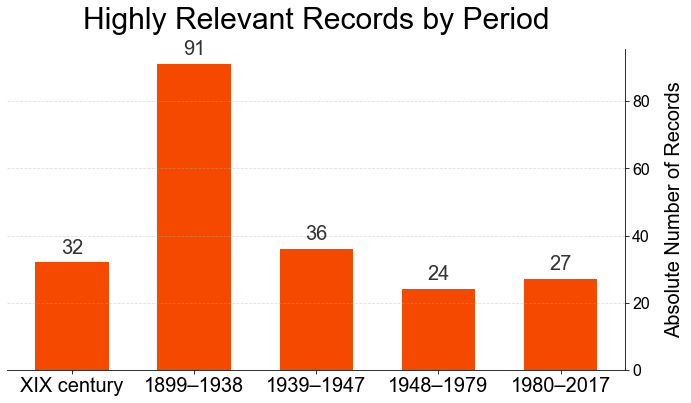

In [15]:
# ==========================================
# VISUALIZATION: HIGHLY RELEVANT RECORDS 
# ==========================================
# This section generates a bar chart displaying the absolute total of highly relevant 
# records (after filtering and manual exclusion rules) per historical period. 

periods = ['XIX century', '1899–1938', '1939–1947', '1948–1979', '1980–2017']
relevant_records = [32, 91, 36, 24, 27]  

bar_color = '#F54900' 

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Inter', 'Arial', 'Helvetica'], 
    'font.size': 20,          
    'axes.titlesize': 30,     
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 16,
    'figure.autolayout': True 
})

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(periods, relevant_records, color=bar_color, width=0.6)

for bar in bars:
    height = bar.get_height()
    formatted_height = f"{int(height):,}".replace(",", " ")
    
    ax.annotate(
        formatted_height,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  
        textcoords="offset points",
        ha='center', 
        va='bottom',
        fontsize=20,
        color='#333333'
    )

ax.set_title("Highly Relevant Records by Period", pad=20)
ax.set_ylabel("Absolute Number of Records", labelpad=15)

# Move the Y-axis ticks and labels to the right side
ax.yaxis.tick_right()                     
ax.yaxis.set_label_position("right")      

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k" if x >= 1000 else int(x)))

# Hide the left spine instead of the right spine to accommodate the flipped axis
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)      

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

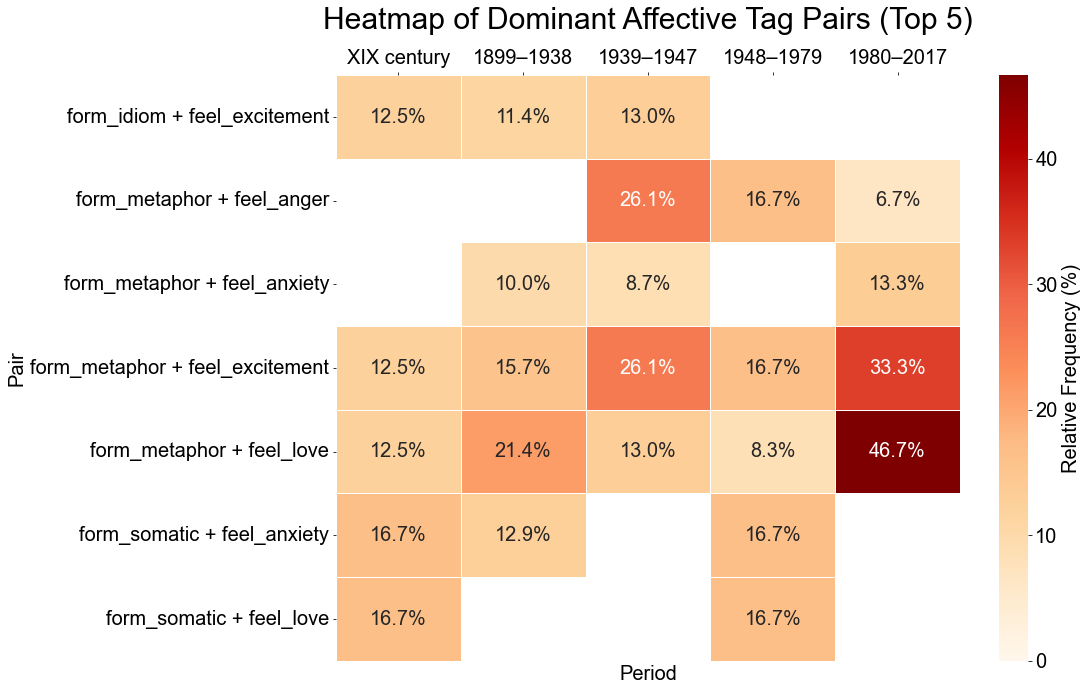

In [54]:
# ==========================================
# HEATMAP OF DOMINANT AFFECTIVE PAIRS
# ==========================================
# Generates a Seaborn heatmap tracking the relative frequency of the 
# Top 5 Form + Feeling pairings over time.

plot_data = []
period_mapping = {
    'Period 1': 'XIX century', 'Period 2': '1899–1938',
    'Period 3': '1939–1947', 'Period 4': '1948–1979', 'Period 5': '1980–2017'
}

for period_name, records in periods_data.items():
    pair_counts = Counter()
    valid_records_count = 0  
    display_period = period_mapping.get(period_name, period_name)
    
    for record in records:
        record_tags = manual_tags.get(str(record.get('ID')), [])
        if should_exclude(record_tags): continue
        valid_records_count += 1
        
        for combo in split_into_combinations(record_tags):
            form_tags = [tag for tag in combo if tag.startswith("form_")]
            feel_tags = [tag for tag in combo if tag.startswith("feel_")]
            
            if form_tags and feel_tags:
                for pair in itertools.product(form_tags, feel_tags):
                    pair_counts[pair] += 1
                
    if pair_counts:
        for pair, count in pair_counts.most_common(5):
            plot_data.append({
                'Period': display_period, 
                'Pair': f"{pair[0]} + {pair[1]}",
                'Frequency': (count / valid_records_count) * 100
            })

df = pd.DataFrame(plot_data)
heatmap_data = df.pivot(index='Pair', columns='Period', values='Frequency')
periods_order = list(period_mapping.values())
heatmap_data = heatmap_data.reindex(columns=periods_order)

plt.rcParams.update({'font.sans-serif': ['Inter', 'Arial'], 'font.size': 20})
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    heatmap_data, 
    annot=heatmap_data.applymap(lambda v: f"{v:.1f}%" if pd.notna(v) else ""),      
    fmt="", cmap="OrRd", cbar_kws={'label': 'Relative Frequency (%)'}, 
    linewidths=1, linecolor='white', vmin=0, ax=ax
)
ax.set_title("Heatmap of Dominant Affective Tag Pairs (Top 5)", pad=20, fontsize=30)
ax.xaxis.tick_top()
plt.show()

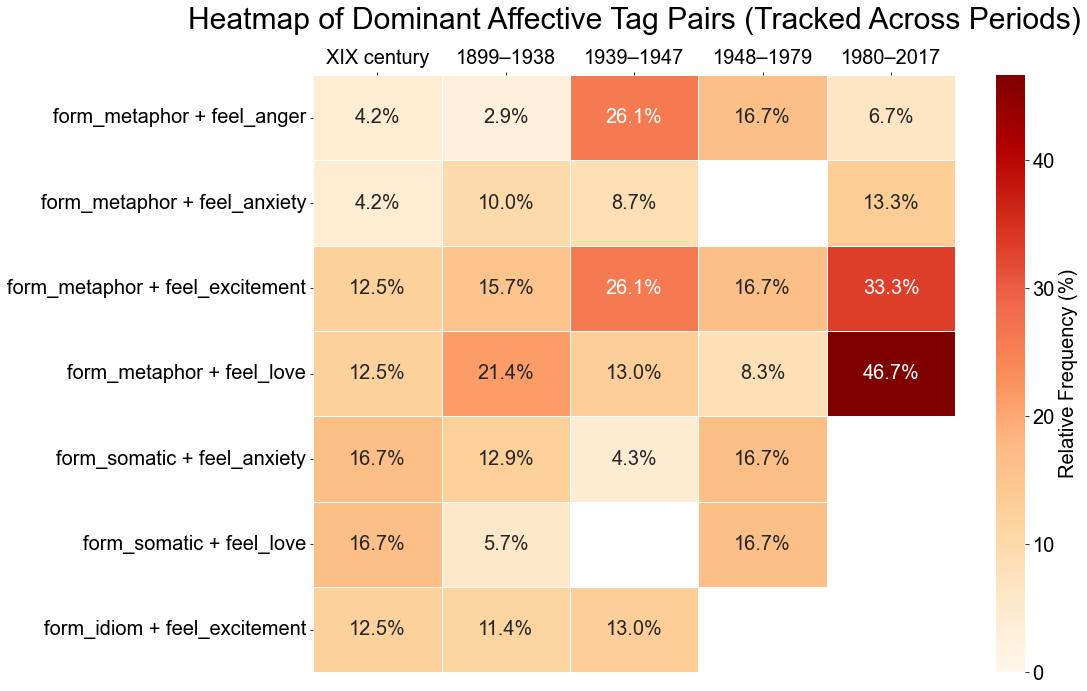

In [55]:
# ==========================================
# HEATMAP OF DOMINANT AFFECTIVE PAIRS (Tracked Across Time)
# ==========================================
# Generates a Seaborn heatmap tracking the relative frequency of the 
# Top 5 Form + Feeling pairings. If a pair hits the Top 5 in ANY period, 
# its frequency is tracked across ALL periods to visualize its full evolution.

plot_data = []
period_mapping = {
    'Period 1': 'XIX century', 'Period 2': '1899–1938',
    'Period 3': '1939–1947', 'Period 4': '1948–1979', 'Period 5': '1980–2017'
}

# STEP 1: Collect all stats and identify the "Top 5" target pairs across any period
all_period_stats = {}
target_pairs = set()

for period_name, records in periods_data.items():
    pair_counts = Counter()
    valid_records_count = 0  
    display_period = period_mapping.get(period_name, period_name)
    
    for record in records:
        record_tags = manual_tags.get(str(record.get('ID')), [])
        if should_exclude(record_tags): continue
        valid_records_count += 1
        
        for combo in split_into_combinations(record_tags):
            form_tags = [tag for tag in combo if tag.startswith("form_")]
            feel_tags = [tag for tag in combo if tag.startswith("feel_")]
            
            if form_tags and feel_tags:
                for pair in itertools.product(form_tags, feel_tags):
                    pair_counts[pair] += 1
    
    all_period_stats[display_period] = {
        'counts': pair_counts,
        'valid_total': valid_records_count
    }
    
    if pair_counts:
        for pair, count in pair_counts.most_common(5):
            target_pairs.add(f"{pair[0]} + {pair[1]}")

# STEP 2: Build the final plot data, ensuring we track the target pairs across ALL periods
for display_period, stats in all_period_stats.items():
    pair_counts = stats['counts']
    valid_records_count = stats['valid_total']
    
    if valid_records_count > 0:
        for pair, count in pair_counts.items():
            pair_str = f"{pair[0]} + {pair[1]}"
            
            if pair_str in target_pairs:
                plot_data.append({
                    'Period': display_period, 
                    'Pair': pair_str,
                    'Frequency': (count / valid_records_count) * 100
                })

# STEP 3: Pivot and Plot
df = pd.DataFrame(plot_data)
heatmap_data = df.pivot(index='Pair', columns='Period', values='Frequency')

periods_order = list(period_mapping.values())
heatmap_data = heatmap_data.reindex(columns=periods_order)

def sort_y_axis(pair_str):
    if "form_metaphor" in pair_str: return 0
    elif "form_somatic" in pair_str: return 1
    else: return 2

sorted_index = sorted(heatmap_data.index.tolist(), key=lambda x: (sort_y_axis(x), x))
heatmap_data = heatmap_data.reindex(sorted_index)

plt.rcParams.update({'font.sans-serif': ['Inter', 'Arial'], 'font.size': 20})
fig, ax = plt.subplots(figsize=(16, 10))

annot_matrix = heatmap_data.applymap(lambda v: f"{v:.1f}%" if pd.notna(v) else "")

sns.heatmap(
    heatmap_data, 
    annot=annot_matrix,      
    fmt="", 
    cmap="OrRd", 
    cbar_kws={'label': 'Relative Frequency (%)'}, 
    linewidths=1, 
    linecolor='white', 
    vmin=0, 
    ax=ax
)

ax.set_title("Heatmap of Dominant Affective Tag Pairs (Tracked Across Periods)", pad=20, fontsize=30)
ax.xaxis.tick_top()
ax.set_ylabel("") 
ax.set_xlabel("") 

plt.yticks(rotation=0, fontsize=20) 
plt.tight_layout()

plt.show()

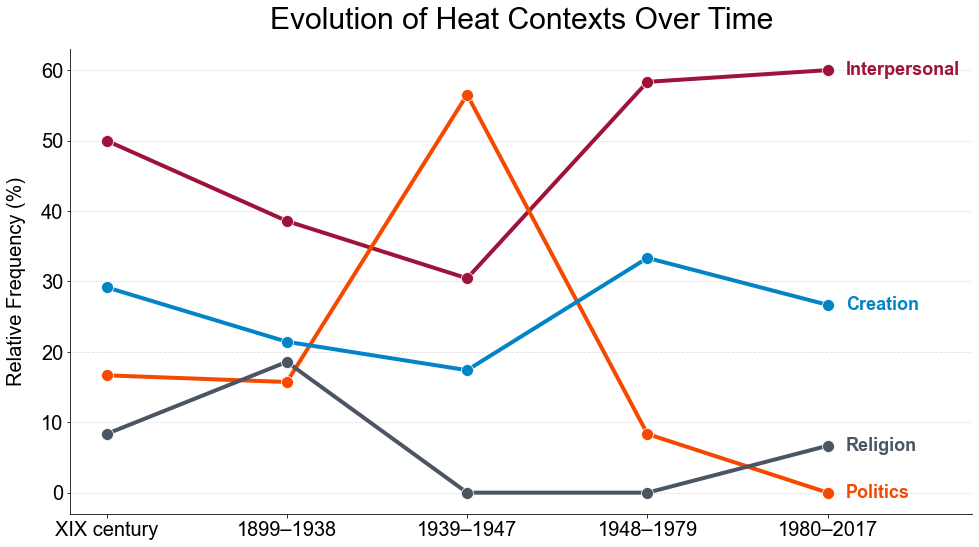

In [60]:
# ==========================================
# VISUALIZATION: EVOLUTION OF CONTEXT TAGS OVER TIME
# ==========================================
# This section extracts all tags starting with 'context_', calculates their 
# relative frequency per period (as a percentage of valid records), and plots 
# them as a multiple line chart to visualize historical shifts (e.g., the rise 
# of politics or the decline of religion).

# 1. Process Data
# ------------------------------------------
plot_data = []

period_mapping = {
    'Period 1': 'XIX century',
    'Period 2': '1899–1938',
    'Period 3': '1939–1947',
    'Period 4': '1948–1979',
    'Period 5': '1980–2017'
}

for period_name, records in periods_data.items():
    valid_records_count = 0
    context_counter = Counter()
    display_period = period_mapping.get(period_name, period_name)
    
    for record in records:
        record_id = str(record.get('ID', 'Unknown'))
        record_tags = manual_tags.get(record_id, [])
        
        if should_exclude(record_tags):
            continue
            
        valid_records_count += 1
        
        for tag in record_tags:
            if tag.startswith("context_"):
                clean_tag = tag.replace("context_", "").capitalize()
                context_counter[clean_tag] += 1
                
    expected_contexts = ['Interpersonal', 'Politics', 'Creation', 'Religion']
    
    for context in expected_contexts:
        count = context_counter.get(context, 0)
        rel_freq = (count / valid_records_count * 100) if valid_records_count > 0 else 0
        
        plot_data.append({
            'Period': display_period,
            'Context': context,
            'Relative Frequency (%)': rel_freq
        })

df_contexts = pd.DataFrame(plot_data)

# 2. Plot Aesthetics & Rendering
# ------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Inter', 'Arial', 'Helvetica'],
    'font.size': 20,          
    'axes.titlesize': 30,     
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.autolayout': True 
})

fig, ax = plt.subplots(figsize=(14, 8))

custom_palette = {
    'Politics': '#F54900',      # Vibrant Vermilion (Your color)
    'Interpersonal': '#9F1239', # Deep Carmine (A darker, grounded red)
    'Creation': '#0284C7',      # Blue Flame (Maintains the stark cool contrast)
    'Religion': '#4B5563'       # Slate Ash (Ties perfectly into your bar charts)
}

sns.lineplot(
    data=df_contexts, 
    x='Period', 
    y='Relative Frequency (%)', 
    hue='Context', 
    palette=custom_palette,
    marker='o',         
    markersize=12,      
    linewidth=4,        
    ax=ax
)

ax.set_title("Evolution of Heat Contexts Over Time", pad=20)
ax.set_ylabel("Relative Frequency (%)", labelpad=15)
ax.set_xlabel("")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.get_legend().remove()

last_period = '1980–2017'
x_offset = 4.1 

for context in expected_contexts:
    final_y_val = df_contexts[(df_contexts['Context'] == context) & (df_contexts['Period'] == last_period)]['Relative Frequency (%)'].values[0]
    
    ax.text(
        x=x_offset, 
        y=final_y_val, 
        s=context, 
        color=custom_palette[context],
        fontweight='bold', 
        fontsize=18,
        va='center'
    )

ax.set_xlim(left=-0.2, right=4.8)

plt.show()

In [31]:
# ==========================================
# TEXT PROCESSING & COLLOCATIONS
# ==========================================
# Cleans the text, lemmatizes using PyMorphy2, and extracts bigrams 
# to identify common linguistic patterns surrounding the heat expressions.

def preprocess_and_tokenize(some_text):
    """Cleans, tokenizes, and lemmatizes text, returning a list of valid words."""
    cleaned_text = re.sub(r'\[|\]|([0-9]|\.\.\.|\\—)|[a-zA-Z]', '', str(some_text))
    tokens = nltk.word_tokenize(cleaned_text.lower())
    lemmatized_tokens = []
    
    for word in tokens:
        lemma = morph.parse(word)[0].normal_form
        if lemma not in stoplist and lemma not in extended_punctuation and len(lemma) >= 3:
            lemmatized_tokens.append(lemma)
            
    return lemmatized_tokens

def analyze_collocations_by_any_tag(periods_dict, tags_dict, target_tags, top_n=10):
    """
    Finds top bigram collocations per period for records containing AT LEAST ONE of the specified tags.
    (e.g., Records with 'form_metaphor' OR 'form_idiom')
    """
    target_set = set(target_tags)
    tags_display = " OR ".join(target_tags)
    
    print(f"--- Top {top_n} Collocations for tags: [{tags_display}] ---")
    print("=" * 60)
    
    for period_name, records in periods_dict.items():
        period_tokens = []
        matching_records_count = 0
        
        for record in records:
            record_tags = set(tags_dict.get(str(record['ID']), []))
            
            if target_set.intersection(record_tags) and "irrelevant" not in record_tags:
                matching_records_count += 1
                period_tokens.extend(preprocess_and_tokenize(record.get('Запись', '')))        

        print(f"\n{period_name} ({matching_records_count} records analyzed):")
        print("-" * 40)

        if len(period_tokens) > 1:
            finder = BigramCollocationFinder.from_words(period_tokens)
            top_collocations = sorted(finder.ngram_fd.items(), key=lambda t: (-t[1], t[0]))[:top_n]
            
            for bigram, count in top_collocations:
                print(f"{bigram[0]} {bigram[1]}: {count}")
        
        else:
            print("Not enough text data to find collocations.")

my_target_tags = ["form_metaphor", "form_idiom"]

analyze_collocations_by_any_tag(
    periods_dict=periods_data, 
    tags_dict=manual_tags, 
    target_tags=my_target_tags
)

--- Top 10 Collocations for tags: [form_metaphor OR form_idiom] ---

Period 1 (22 records analyzed):
----------------------------------------
софья степанович: 8
кровь кипеть: 6
друг друг: 4
священный огонь: 4
февраль папенька: 4
анна петрович: 3
держать рука: 3
любить любить: 3
мих говорить: 3
наташа смерть: 3

Period 2 (66 records analyzed):
----------------------------------------
ольга николаевич: 23
неправда анархист: 8
кровь кипеть: 7
всякий случай: 5
герман александрович: 5
друг друг: 5
женский стиль: 5
христос церковь: 5
электрический ток: 5
вплотную прилегать: 4

Period 3 (32 records analyzed):
----------------------------------------
опушка лес: 7
младший лейтенант: 6
голова сердце: 5
любить любить: 5
старший лейтенант: 5
генерал галицкий: 4
генерал-майор галицкий: 4
иван журавлёв: 4
красный армия: 4
лейтенант васильев: 4

Period 4 (16 records analyzed):
----------------------------------------
иао уао: 8
желать хороший: 7
припев конец: 7
конец песня: 6
танечка желать: 6
коми

In [37]:
# ==========================================
# LINGUISTIC PHRASE MAPPING (BIGRAM TO FULL TAG COMBINATION)
# ==========================================
# This section isolates specific target phrases (e.g., "сердце гореть" / "the heart burns") 
# to see which complete combinations of emotional and contextual tags were manually 
# assigned to them across different historical periods. 

from collections import Counter
import nltk 

# 1. HELPER FUNCTION TO PREVENT CROSS-POLLINATION
# ------------------------------------------
def split_into_combinations(tags):
    combos = []
    current_combo = []
    has_form = False

    for tag in tags:
        if tag.startswith("form_"):
            if has_form:
                combos.append(current_combo)
                current_combo = [tag]
            else:
                current_combo.append(tag)
                has_form = True
        else:
            current_combo.append(tag)
            
    if current_combo:
        combos.append(current_combo)

    return combos

# 2. MAIN SEARCH FUNCTION
# ------------------------------------------
def find_tag_combinations_for_bigrams(periods_dict, tags_dict, target_bigrams, top_n=10):
    target_bigram_tuples = set(tuple(b.lower().split()) for b in target_bigrams)
    
    bigrams_display = ", ".join(target_bigrams)
    print(f"--- Top {top_n} Tag Combinations for Bigrams: [{bigrams_display}] ---")
    print("=" * 70)
    
    for period_name, records in periods_dict.items():
        combo_counter = Counter()
        matching_records_count = 0
        
        for record in records:
            record_id = str(record.get('ID', 'Unknown'))
            record_tags = tags_dict.get(record_id, [])
            
            if not record_tags or "irrelevant" in record_tags:
                continue
                
            text = record.get('Запись', '')
            tokens = preprocess_and_tokenize(text)
            record_bigrams = set(nltk.bigrams(tokens))
            
            if target_bigram_tuples.intersection(record_bigrams):
                matching_records_count += 1
                
                chunks = split_into_combinations(record_tags)
                
                for chunk in chunks:
                    def sort_key(t):
                        if t.startswith('form_'): return 0
                        if t.startswith('feel_'): return 1
                        if t.startswith('context_'): return 2
                        return 3
                    
                    chunk.sort(key=lambda x: (sort_key(x), x))
                    
                    combo_counter[tuple(chunk)] += 1
                    
        print(f"\n{period_name} ({matching_records_count} records matched):")
        print("-" * 50)
        
        if combo_counter:
            top_combos = sorted(combo_counter.items(), key=lambda t: (-t[1], t[0]))[:top_n]
            for combo, count in top_combos:
                relative_freq = (count / matching_records_count) * 100
                formatted_combo = ", ".join(f'"{tag}"' for tag in combo)
                print(f'{formatted_combo}: {count} ({relative_freq:.1f}%)')
        else:
            print("No matching tag combinations found for these bigrams.")

# 3. EXECUTION
# ------------------------------------------
my_target_bigrams = ["сердце гореть", "гореть сердце"]

find_tag_combinations_for_bigrams(
    periods_dict=periods_data, 
    tags_dict=manual_tags, 
    target_bigrams=my_target_bigrams, 
    top_n=10
)

--- Top 10 Tag Combinations for Bigrams: [сердце гореть, гореть сердце] ---

Period 1 (2 records matched):
--------------------------------------------------
"form_metaphor", "feel_excitement", "context_interpersonal", "subject_other": 1 (50.0%)
"form_somatic", "feel_anxiety", "context_interpersonal": 1 (50.0%)

Period 2 (5 records matched):
--------------------------------------------------
"form_metaphor", "feel_love", "context_religion": 2 (40.0%)
"form_metaphor", "feel_anger", "context_politics", "subject_other": 1 (20.0%)
"form_metaphor", "feel_anxiety", "context_religion": 1 (20.0%)
"form_metaphor", "feel_excitement", "context_religion": 1 (20.0%)

Period 3 (4 records matched):
--------------------------------------------------
"form_metaphor", "feel_anger", "context_politics": 1 (25.0%)
"form_metaphor", "feel_anger", "context_politics", "quote": 1 (25.0%)
"form_metaphor", "feel_love", "context_interpersonal": 1 (25.0%)
"form_metaphor", "feel_love", "context_interpersonal", "subj

In [58]:
# ==========================================
# TEXT EXTRACTION & QUALITATIVE CLOSE-READING
# ==========================================
# This section provides a tool to extract and format specific primary source 
# diary entries based on targeted regex patterns (e.g., "the heart burns").  
# Output is limited to 5 records to keep the notebook readable.

def print_records_by_phrase(periods_dict, tags_dict, target_regex, max_records=5):
    """
    Searches for a specific phrase (regex) across all periods,
    neatly prints the matching records, and explicitly ignores 'irrelevant' ones.
    """
    print(f"Searching for phrase pattern: '{target_regex.pattern}'\n")
    print("=" * 80)
    
    match_count = 0
    line_width = 80
    
    for period_name, records in periods_dict.items():
        for record in records:
            record_id = str(record.get('ID', 'Unknown'))
            
            record_tags = tags_dict.get(record_id, [])
            
            if "irrelevant" in record_tags:
                continue
                
            text = str(record.get('Запись', ''))
            
            if re.search(target_regex, text):
                match_count += 1
                
                tags_display = ", ".join(record_tags) if record_tags else "No tags"
                
                print(f"Period: {period_name} | ID: {record_id}")
                print(f"Tags: [{tags_display}]")
                print("-" * 80)
                
                wrapped_text = "\n".join([textwrap.fill(p, width=line_width) for p in text.split('\n')])
                
                print(wrapped_text)
                print("=" * 80 + "\n")
                
                # STOP CONDITION: Limit output to keep notebook clean
                if match_count >= max_records:
                    print(f"--- Output limited to first {max_records} matches ---")
                    return
                
    if match_count == 0:
        print("No valid records found matching that phrase.")
    else:
        print(f"Total valid matching records found: {match_count}")

# This regex captures combinations and grammatical cases for "сердце горит" / "горит сердце"
# allowing up to 2 words in between the main terms.
target_pattern = re.compile(
    r'(?:сердце)\s+(?:\w+\s+){0,2}(?:горит)|'
    r'(?:горит)\s+(?:\w+\s+){0,2}(?:сердце)',
    re.IGNORECASE
) 

print_records_by_phrase(
    periods_dict=periods_data,
    tags_dict=manual_tags,
    target_regex=target_pattern,
    max_records=5
)

Searching for phrase pattern: '(?:сердце)\s+(?:\w+\s+){0,2}(?:горит)|(?:горит)\s+(?:\w+\s+){0,2}(?:сердце)'

Period: Period 1 | ID: 442348
Tags: [form_metaphor, feel_excitement, context_interpersonal, subject_other]
--------------------------------------------------------------------------------
Именины Филарета. Подарила ему ночник в готическом стиле. Он определил мне в
религиозные наставники молодого священника — отца Василия Бажанова, человека
просвещенного ума, весьма красноречивого, с очень милосердным и кротким
сердцем<com id="153873239214219"/>. Трижды в неделю он приходит к нам для
приобщения меня к лону православной церкви. Хотя я и православная<com
id="153873239214220"/>, однако почти не знаю ее обрядов. Вообще, как я полагаю,
религию было бы полезно изучать дважды — сначала в переходной период от детства
к юности, а затем по достижению разумного возраста. В 13-14 лет душа, бесспорно,
чище, и небесное для нее более доступно, чем земное; следовательно, она легче
приобщается к 

In [38]:
# ==========================================
# QUALITATIVE CLOSE-READING EXTRACTION
# ==========================================
# Retrieves a strictly limited sample of primary source text for qualitative review.

target_tags = {"form_somatic", "feel_anxiety"}
matched_count = 0

print(f"Searching for records with tags: {', '.join(target_tags)}\n")
print("=" * 80)

for period_name, records in periods_data.items():
    for record in records:
        record_id = str(record.get('ID', 'Unknown'))
        record_tags = set(manual_tags.get(record_id, []))
        
        # Check if ALL target tags are present
        if target_tags.issubset(record_tags) and "irrelevant" not in record_tags:
            matched_count += 1
            
            print(f"ID: {record_id} | Period: {period_name}")
            print(f"Tags: {', '.join(record_tags)}")
            print("-" * 80)
            print(record.get('Запись', '').strip())
            print("=" * 80 + "\n")
            
            # STRICT LIMIT: Stop after printing exactly 5 records
            if matched_count >= 5:
                break
    if matched_count >= 5:
        break
        
if matched_count == 0:
    print("No records found matching those tags.")

Searching for records with tags: form_somatic, feel_anxiety

ID: 182790 | Period: Period 1
Tags: form_somatic, feel_anxiety, context_interpersonal
--------------------------------------------------------------------------------
Сегодня, когда я пришла обедать, M-me Р. мне сказала, что какой-то господин меня спрашивал и хотел притти после. Это меня удивило, что ко мне кто-то пришел. Я невольно думала о С[альвадоре], и сердце мое забилось.    
— Молодой человек? — спросила я.    
— Да, высокий.    
— С бородой — сказала я, предполагая молодого Гер[цена].    
— С черной бородой.    
Я не могла придумать, кто бы это мог быть. После обеда меня позвали, сказав, что кто-то желает меня видеть. Это был высокий стройный молодой человек. Он мне сказал, что он от С[альвадора]. Я вспыхнула и задрожала. Я взяла свечку и попросила его итти за мной в мою комнату. Войдя, я подала ему стул и затворила дверь. Потом я села и спросила, что ему нужно от меня (голос мой очень дрожал). Он принес мне 15 ф. и с